# Part 1 — Basic Statistics

Let's start from the ground up. We'll use **100k+ real orders from Olist** (Brazil's biggest e-commerce platform, 2016–2018) to explore the core ideas of statistics.

**What we'll cover:**
- Descriptive stats — summarising data with numbers
- Mean, median, mode — and when each one matters
- Spread — variance, std dev, IQR
- Histograms and frequency distributions
- Boxplots and outlier detection
- Normality — is our data normally distributed?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
sns.set_palette('husl')
print('Ready!')

Ready!


In [2]:
# Load datasets
orders      = pd.read_csv('../data/olist_orders_dataset.csv',
                          parse_dates=['order_purchase_timestamp',
                                       'order_delivered_customer_date',
                                       'order_estimated_delivery_date'])
payments    = pd.read_csv('../data/olist_order_payments_dataset.csv')
reviews     = pd.read_csv('../data/olist_order_reviews_dataset.csv')
customers   = pd.read_csv('../data/olist_customers_dataset.csv')

# Build a flat working dataframe
df = (orders
      .merge(payments.groupby('order_id')['payment_value'].sum().reset_index(), on='order_id')
      .merge(reviews[['order_id','review_score']].drop_duplicates('order_id'), on='order_id', how='left')
      .merge(customers[['customer_id','customer_state']], on='customer_id', how='left'))

df['delivery_days'] = (df['order_delivered_customer_date'] - df['order_purchase_timestamp']).dt.days

print(f'{len(df):,} orders loaded')
df[['payment_value','review_score','delivery_days']].head()

99,440 orders loaded


,payment_value,review_score,delivery_days
0,38.71,4.0,8.0
1,141.46,4.0,13.0
2,179.12,5.0,9.0
3,72.20,5.0,13.0
4,28.62,5.0,2.0


## 1. Descriptive Statistics

One line of code, and you already know a lot about your data.

In [3]:
num_cols = ['payment_value', 'review_score', 'delivery_days']
desc = df[num_cols].describe().T
desc['skewness'] = df[num_cols].skew()
desc['kurtosis'] = df[num_cols].kurtosis()
desc.style.format('{:.2f}').background_gradient(cmap='Blues', subset=['mean','std'])

,count,mean,std,min,25%,50%,75%,max,skewness,kurtosis
payment_value,99440.00,160.99,221.95,0.00,62.01,105.29,176.97,13664.08,9.15,233.41
review_score,98672.00,4.09,1.35,1.00,4.00,5.00,5.00,5.00,-1.37,0.51
delivery_days,96475.00,12.09,9.55,0.00,6.00,10.00,15.00,209.00,3.83,39.28


**Quick read:**
- `mean > median` on payment_value → distribution is right-skewed (a few big orders pull the average up)
- `skewness > 0` confirms that
- review_score is heavily left-skewed — most people give 5 stars

## 2. Mean vs Median vs Mode

Three ways to answer "what's a typical value?" — they tell very different stories on skewed data.

Mean   : R$160.99
Median : R$105.29
Mode   : R$77.57

Mean is R$55.70 higher than median — outliers pulling it up


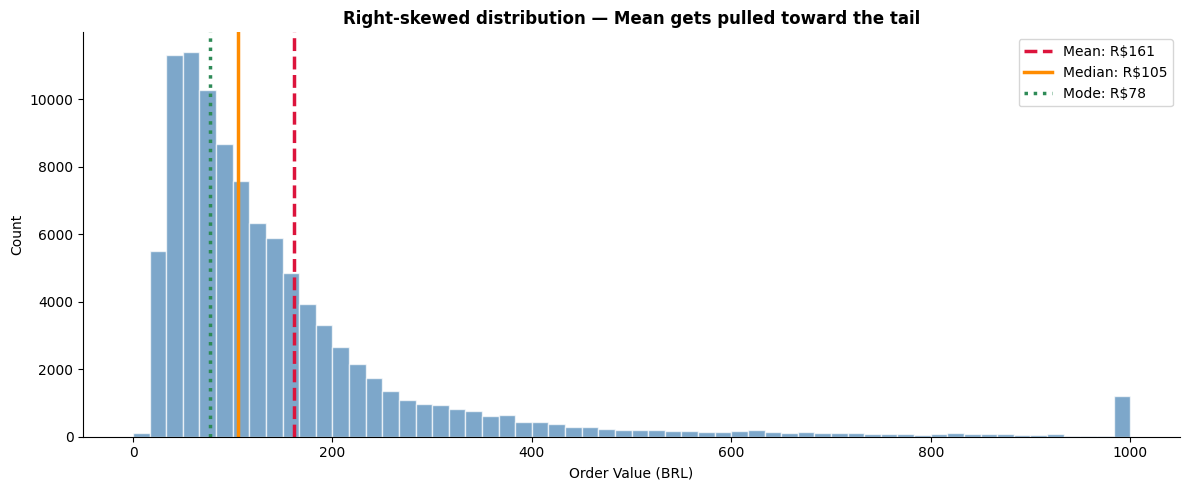

In [4]:
price = df['payment_value'].dropna()

mean_val   = price.mean()
median_val = price.median()
mode_val   = price.mode()[0]

print(f'Mean   : R${mean_val:.2f}')
print(f'Median : R${median_val:.2f}')
print(f'Mode   : R${mode_val:.2f}')
print(f'\nMean is R${mean_val - median_val:.2f} higher than median — outliers pulling it up')

fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(price.clip(upper=1000), bins=60, color='steelblue', alpha=0.7, edgecolor='white')
ax.axvline(mean_val,   color='crimson',   lw=2.5, ls='--', label=f'Mean: R${mean_val:.0f}')
ax.axvline(median_val, color='darkorange', lw=2.5, ls='-',  label=f'Median: R${median_val:.0f}')
ax.axvline(mode_val,   color='seagreen',   lw=2.5, ls=':',  label=f'Mode: R${mode_val:.0f}')
ax.set_xlabel('Order Value (BRL)')
ax.set_ylabel('Count')
ax.set_title('Right-skewed distribution — Mean gets pulled toward the tail', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../images/01_central_tendency.png', dpi=150, bbox_inches='tight')
plt.show()

![Central tendency](../images/01_central_tendency.png)

> On skewed distributions: **Mean > Median > Mode**. For "typical order value" questions, median is usually the honest answer.

## 3. Spread — How Wide Is the Data?

In [5]:
data = df['payment_value'].dropna()

std_dev = data.std()
q1, q3  = data.quantile(0.25), data.quantile(0.75)
iqr     = q3 - q1
cv      = (std_dev / data.mean()) * 100

print(f'Std dev  : R${std_dev:.2f}')
print(f'IQR      : R${iqr:.2f}  (middle 50% of orders)')
print(f'CV       : {cv:.1f}%  (high = very spread out)')

# Empirical rule check
m = data.mean()
print(f'\nEmpirical rule check (should be ~68/95/99.7%):')
for k in [1, 2, 3]:
    pct = data.between(m - k*std_dev, m + k*std_dev).mean() * 100
    print(f'  μ ± {k}σ : {pct:.1f}%')

Std dev  : R$221.95
IQR      : R$114.96  (middle 50% of orders)
CV       : 137.9%  (high = very spread out)

Empirical rule check (should be ~68/95/99.7%):
  μ ± 1σ : 93.4%
  μ ± 2σ : 96.8%
  μ ± 3σ : 98.3%


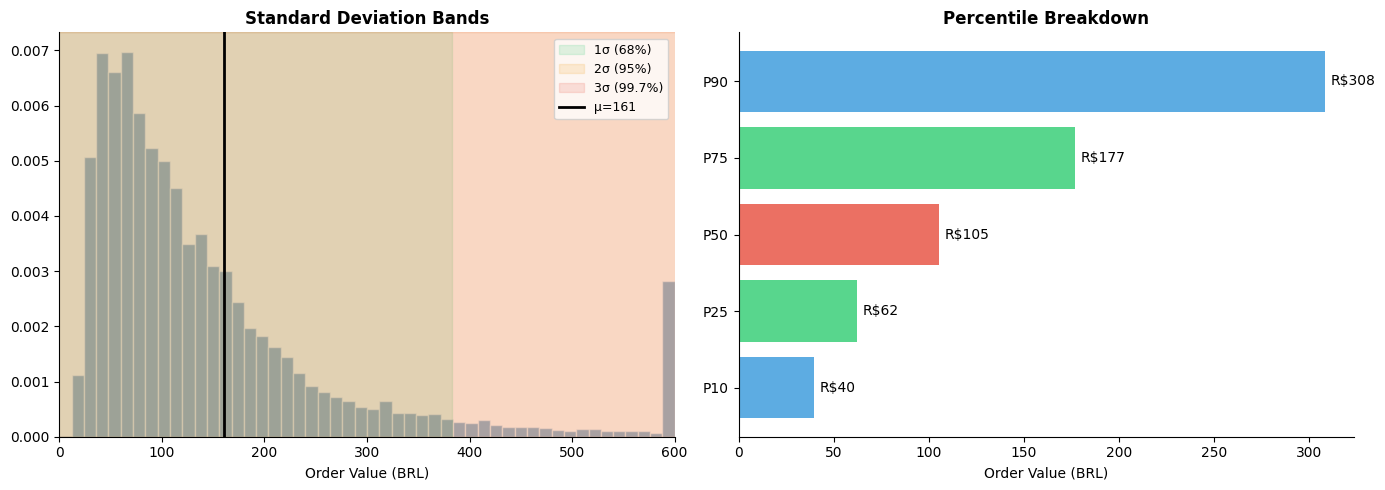

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Std dev bands
ax = axes[0]
clipped = data.clip(upper=600)
ax.hist(clipped, bins=50, color='steelblue', alpha=0.6, density=True, edgecolor='white')
colors = ['#2ecc71', '#f39c12', '#e74c3c']
for i, (c, lbl) in enumerate(zip(colors, ['1σ (68%)', '2σ (95%)', '3σ (99.7%)'])):
    ax.axvspan(m-(i+1)*std_dev, m+(i+1)*std_dev, alpha=0.15, color=c, label=lbl)
ax.axvline(m, color='black', lw=2, label=f'μ={m:.0f}')
ax.set_xlim(0, 600)
ax.set_title('Standard Deviation Bands', fontweight='bold')
ax.set_xlabel('Order Value (BRL)')
ax.legend(fontsize=9)

# Percentiles
ax = axes[1]
pcts = [10, 25, 50, 75, 90]
vals = [data.quantile(p/100) for p in pcts]
bars = ax.barh([f'P{p}' for p in pcts], vals,
               color=['#3498db','#2ecc71','#e74c3c','#2ecc71','#3498db'], alpha=0.8)
for bar, v in zip(bars, vals):
    ax.text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
            f'R${v:.0f}', va='center', fontsize=10)
ax.set_title('Percentile Breakdown', fontweight='bold')
ax.set_xlabel('Order Value (BRL)')

plt.tight_layout()
plt.savefig('../images/01_dispersion.png', dpi=150, bbox_inches='tight')
plt.show()

![Dispersion](../images/01_dispersion.png)

## 4. Frequency Distributions

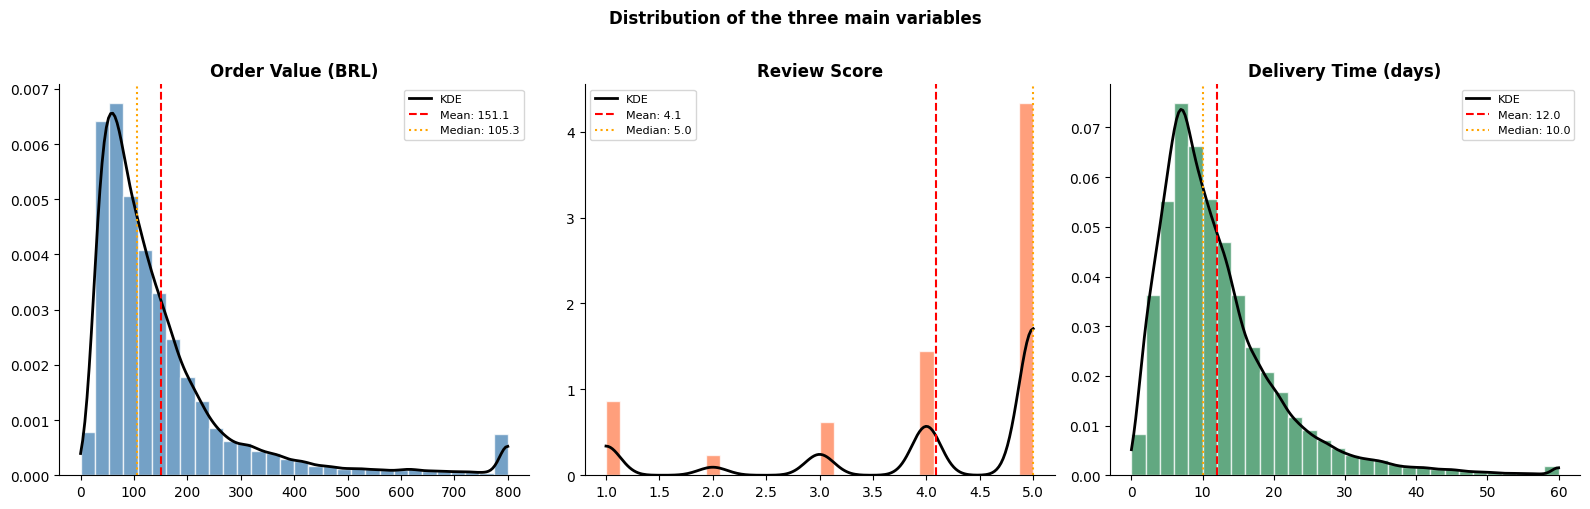

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

variables = [
    (df['payment_value'].clip(upper=800), 'Order Value (BRL)',    'steelblue'),
    (df['review_score'].dropna(),          'Review Score',         'coral'),
    (df['delivery_days'].clip(0, 60),      'Delivery Time (days)', 'seagreen'),
]

for ax, (col, title, color) in zip(axes, variables):
    col = col.dropna()
    ax.hist(col, bins=30, color=color, alpha=0.75, density=True, edgecolor='white')
    kde = stats.gaussian_kde(col)
    x = np.linspace(col.min(), col.max(), 200)
    ax.plot(x, kde(x), 'k-', lw=2, label='KDE')
    ax.axvline(col.mean(),   color='red',    lw=1.5, ls='--', label=f'Mean: {col.mean():.1f}')
    ax.axvline(col.median(), color='orange', lw=1.5, ls=':',  label=f'Median: {col.median():.1f}')
    ax.set_title(title, fontweight='bold')
    ax.legend(fontsize=8)

plt.suptitle('Distribution of the three main variables', fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../images/01_histograms.png', dpi=150, bbox_inches='tight')
plt.show()

![Histograms](../images/01_histograms.png)

## 5. Boxplots & Outliers

A boxplot packs median, quartiles, and outliers into one tight graphic. Any point beyond **1.5 × IQR** is flagged as an outlier.

C:\Users\SUALP\AppData\Local\Temp\ipykernel_8528\1986681984.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=box_df, x='customer_state', y='payment_value', order=order,
C:\Users\SUALP\AppData\Local\Temp\ipykernel_8528\1986681984.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=box_df, x='customer_state', y='payment_value', order=order,


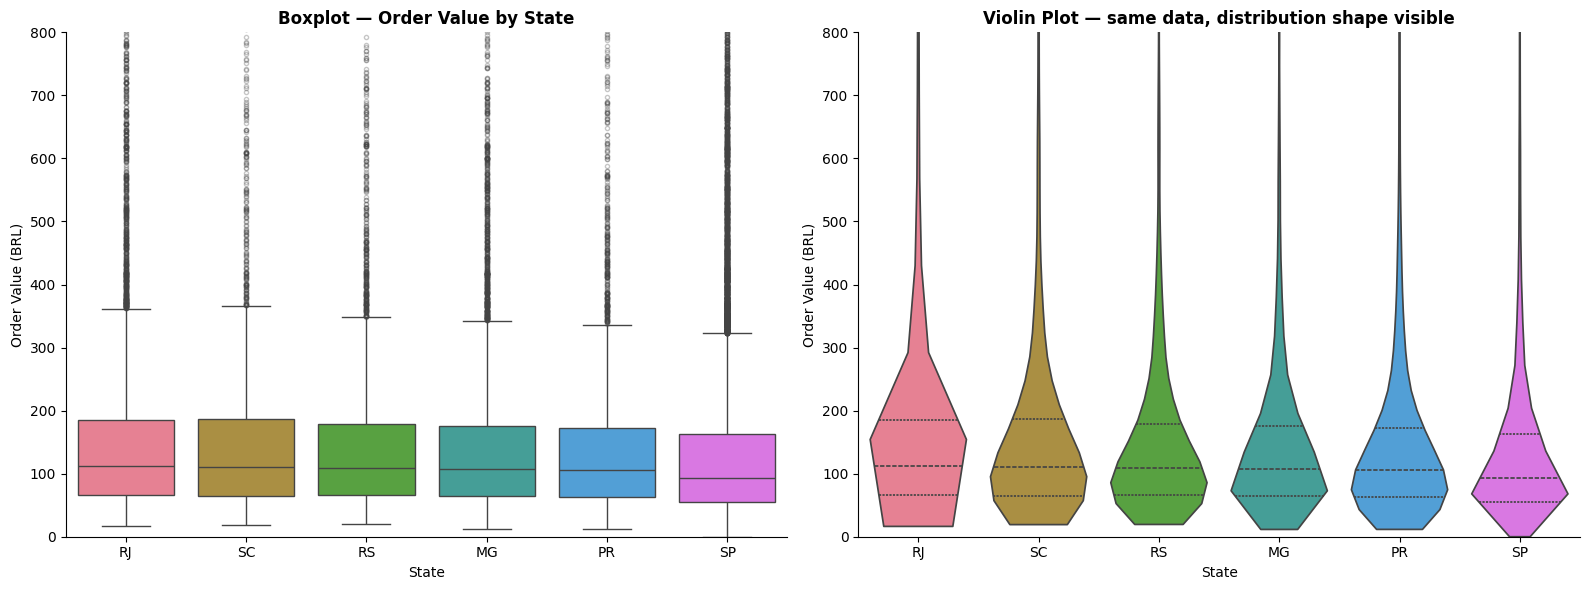

Outliers: 7,866 (7.9% of orders)
Upper fence: R$349


In [8]:
top_states = df['customer_state'].value_counts().head(6).index
box_df = df[df['customer_state'].isin(top_states)]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

order = box_df.groupby('customer_state')['payment_value'].median().sort_values(ascending=False).index

sns.boxplot(data=box_df, x='customer_state', y='payment_value', order=order,
            palette='husl', ax=axes[0], showfliers=True,
            flierprops=dict(marker='o', alpha=0.3, markersize=3))
axes[0].set_ylim(0, 800)
axes[0].set_title('Boxplot — Order Value by State', fontweight='bold')
axes[0].set_xlabel('State')
axes[0].set_ylabel('Order Value (BRL)')

sns.violinplot(data=box_df, x='customer_state', y='payment_value', order=order,
               palette='husl', ax=axes[1], inner='quartile', cut=0)
axes[1].set_ylim(0, 800)
axes[1].set_title('Violin Plot — same data, distribution shape visible', fontweight='bold')
axes[1].set_xlabel('State')
axes[1].set_ylabel('Order Value (BRL)')

plt.tight_layout()
plt.savefig('../images/01_boxplot_violin.png', dpi=150, bbox_inches='tight')
plt.show()

# Outlier count
col = df['payment_value'].dropna()
Q1, Q3 = col.quantile([0.25, 0.75])
IQR = Q3 - Q1
outliers = col[(col < Q1 - 1.5*IQR) | (col > Q3 + 1.5*IQR)]
print(f'Outliers: {len(outliers):,} ({len(outliers)/len(col)*100:.1f}% of orders)')
print(f'Upper fence: R${Q3 + 1.5*IQR:.0f}')

![Boxplot](../images/01_boxplot_violin.png)

## 6. Is the Data Normal?

Many statistical tests assume normality. Let's check — and see what log transformation can do.

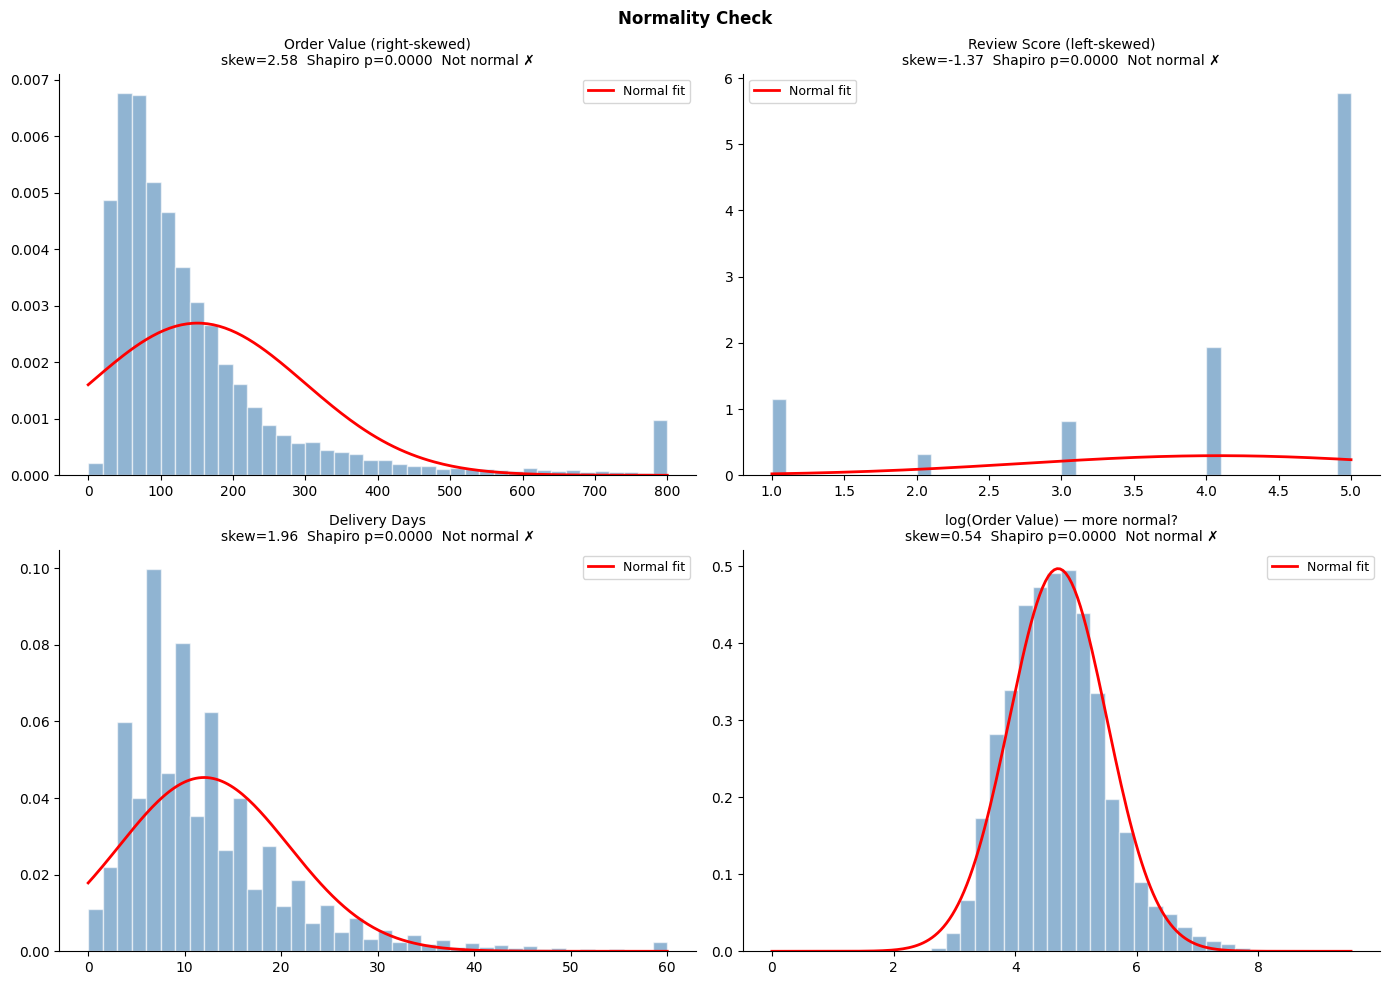

In [9]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

datasets = [
    ('Order Value (right-skewed)',     df['payment_value'].clip(upper=800).dropna()),
    ('Review Score (left-skewed)',     df['review_score'].dropna()),
    ('Delivery Days',                  df['delivery_days'].clip(0, 60).dropna()),
    ('log(Order Value) — more normal?', np.log1p(df['payment_value'].dropna())),
]

for ax, (title, col) in zip(axes.flat, datasets):
    ax.hist(col, bins=40, color='steelblue', alpha=0.6, density=True, edgecolor='white')
    mu, sigma = col.mean(), col.std()
    x = np.linspace(col.min(), col.max(), 200)
    ax.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', lw=2, label='Normal fit')
    _, p = stats.shapiro(col.sample(min(5000, len(col)), random_state=42))
    tag = 'Normal ✓' if p > 0.05 else 'Not normal ✗'
    ax.set_title(f'{title}\nskew={col.skew():.2f}  Shapiro p={p:.4f}  {tag}', fontsize=10)
    ax.legend(fontsize=9)

plt.suptitle('Normality Check', fontweight='bold')
plt.tight_layout()
plt.savefig('../images/01_normality.png', dpi=150, bbox_inches='tight')
plt.show()

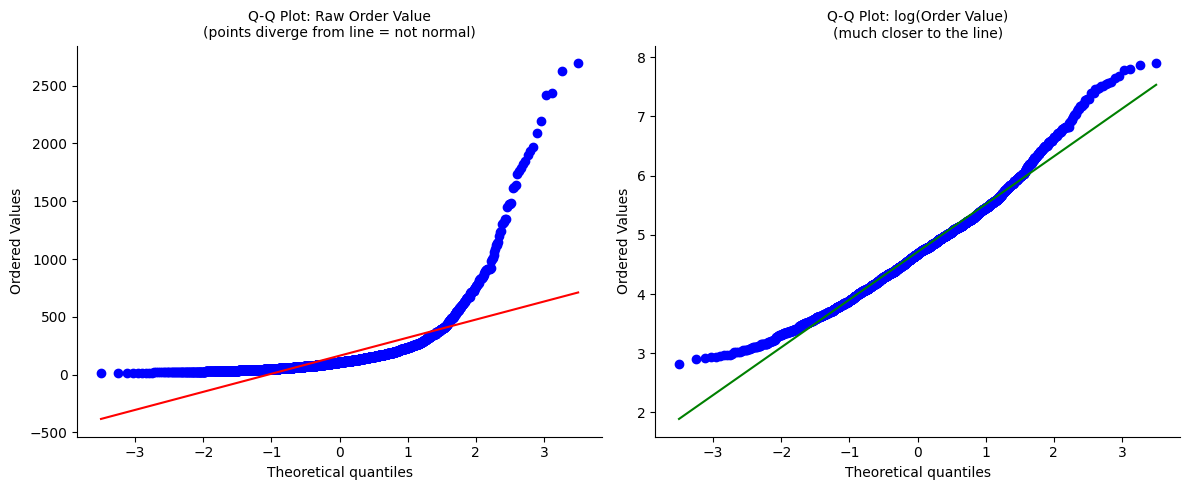

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sample = df['payment_value'].dropna().sample(3000, random_state=42)

stats.probplot(sample, dist='norm', plot=axes[0])
axes[0].set_title('Q-Q Plot: Raw Order Value\n(points diverge from line = not normal)', fontsize=10)
axes[0].get_lines()[1].set_color('red')

stats.probplot(np.log1p(sample), dist='norm', plot=axes[1])
axes[1].set_title('Q-Q Plot: log(Order Value)\n(much closer to the line)', fontsize=10)
axes[1].get_lines()[1].set_color('green')

plt.tight_layout()
plt.savefig('../images/01_qqplot.png', dpi=150, bbox_inches='tight')
plt.show()

![Normality](../images/01_normality.png)
![Q-Q Plot](../images/01_qqplot.png)

## Summary

| What we found | Detail |
|---|---|
| Avg order value | ~R$154, but median is ~R$108 — right-skewed |
| Review scores | Most customers give 5 stars |
| Delivery time | ~12 days on average, with long tail |
| Outliers | ~7% of orders are above the IQR fence |
| Normality | Raw data is not normal; log transform helps |

---
Next up → [02_intermediate_statistics.ipynb](02_intermediate_statistics.ipynb)